In [1]:
import numpy as np
import sys, os 
sys.path.append('../Netket/')
sys.path.append('../ClusterExpansion/')
import netket as nk
import itertools
import matplotlib.pyplot as plt 
import cluster_expansion as ce
# from cluster_expansion import fwht_coeffs_in_cluster_col_order, prepare_fwht_meta_cached, compress_and_reconstruct_cached, _get_topk_indices_jit
import analysis
from analysis import std_phase, ipr, pca_entropy, renyi_entropy, mean_amplitude, uniform_state_overlap, infidelity
import pandas as pd
from functools import partial
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.feature_selection import mutual_info_regression
from xgboost import XGBRegressor

import torch 
import torch.nn as nn
import torch.optim as optim


ERROR:2026-02-24 14:47:06,627:jax._src.xla_bridge:475: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/scratch/ashankar/DataMiningRBMs/.venv/lib/python3.13/site-packages/jax/_src/xla_bridge.py", line 473, in discover_pjrt_plugins
    plugin_module.initialize()
    ~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "/scratch/ashankar/DataMiningRBMs/.venv/lib/python3.13/site-packages/jax_plugins/xla_cuda12/__init__.py", line 328, in initialize
    _check_cuda_versions(raise_on_first_error=True)
    ~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/scratch/ashankar/DataMiningRBMs/.venv/lib/python3.13/site-packages/jax_plugins/xla_cuda12/__init__.py", line 285, in _check_cuda_versions
    local_device_count = cuda_versions.cuda_device_count()
RuntimeError: jaxlib/cuda/versions_helpers.cc:113: operation cuInit(0) failed: Unknown CUDA error 303; cuGetErrorName failed. This probably means that JAX was unable to load 

∣NK⟩ Tip: Use driver.run(..., timeit=True) to know where your dominant cost is.

In [2]:
data_root = '..'
data_dirs_set = ['data_optimal_basis_rbm', 'extended_data_optimal_basis_rbm']
datadirs = [f'{data_root}/data/{data_dir_val}' for data_dir_val in data_dirs_set]
h5_files_opt = [f'{data_root}/data/{data_dir_val}/{fp}' for data_dir_val in datadirs for fp in os.listdir(data_dir_val) if fp.endswith('.h5')]

df_opt = analysis.load_outputs_to_dataframe_mult_thread(h5_files_opt, load_eigenstates=False, num_workers=4)
df_opt["idx"] = df_opt["file"].apply(lambda x: int(os.path.basename(x).split('_')[2]))
print(len(df_opt))

df_opt = df_opt[df_opt['E_gap'] > 0]
print(len(df_opt))

700
629


In [3]:

hilb_test = nk.hilbert.Spin(s=0.5, N=16)

def sorted_coeffs_from_psi(psi):
    coeffs = ce.fwht_coeffs_in_cluster_col_order(np.log(psi), hilb_test) #This is fourier transform, not cluster expn
    return np.sort(np.abs(coeffs))[::-1][:100] # take top 100 coefficients

sorted_cluster_coeffs = df_opt["psi_0"].apply(sorted_coeffs_from_psi)

ce_data_df = pd.DataFrame(
    sorted_cluster_coeffs.tolist(),
    index=sorted_cluster_coeffs.index,
)
ce_data_df.columns = [f"c{i}" for i in range(ce_data_df.shape[1])]
ce_data_df["Delta_E"] = df_opt.loc[ce_data_df.index, "Delta_E"]

# quick check
ce_data_df.head()


,c0,c1,c2,c3,c4,c5,c6,c7,c8,c9,...,c91,c92,c93,c94,c95,c96,c97,c98,c99,Delta_E
0,5.783397,0.111582,0.111582,0.111582,0.111582,0.111582,0.111582,0.111582,0.111582,0.111582,...,0.009738,0.009738,0.009738,0.009738,0.009738,0.009738,0.009738,0.009738,0.009738,0.000382
1,5.610612,0.133536,0.133536,0.133536,0.133536,0.133536,0.133536,0.133536,0.133536,0.133536,...,0.013426,0.013426,0.010247,0.010247,0.010247,0.010247,0.010247,0.010247,0.010247,0.002817
2,5.949305,0.133340,0.133340,0.133340,0.133340,0.133340,0.133340,0.133340,0.133340,0.133340,...,0.033814,0.033814,0.031155,0.031155,0.031155,0.031155,0.031155,0.031155,0.031155,0.010822
3,6.093950,0.651726,0.068799,0.068799,0.068799,0.068799,0.068799,0.068799,0.068799,0.068799,...,0.035316,0.035316,0.035316,0.035316,0.035316,0.035316,0.035316,0.035316,0.035316,0.001868
4,5.736505,0.104454,0.104454,0.104454,0.104454,0.104454,0.104454,0.104454,0.104454,0.104454,...,0.017439,0.017439,0.017153,0.017153,0.017153,0.017153,0.017153,0.017153,0.017153,0.001916


In [11]:

# split into train/test and train a simple CNN on the ci features

# prepare numpy arrays
X = ce_data_df.drop("Delta_E", axis=1).values.astype(np.float32)
y = ce_data_df["Delta_E"].values.astype(np.float32)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# convert to torch tensors and add channel dimension for conv
X_train_t = torch.from_numpy(X_train).unsqueeze(1)   # shape [N,1,F]
y_train_t = torch.from_numpy(y_train).unsqueeze(1)
X_test_t = torch.from_numpy(X_test).unsqueeze(1)
y_test_t = torch.from_numpy(y_test).unsqueeze(1)

# define a simple 1D CNN
input_dim = X_train.shape[1]
model = nn.Sequential(
    nn.Conv1d(1, 16, kernel_size=4, padding=1),
    nn.ReLU(),
    nn.Conv1d(16, 32, kernel_size=4, padding=1),
    nn.ReLU(),
    nn.Flatten(),
    nn.Linear(32 * input_dim, 64),
    nn.ReLU(),
    nn.Linear(64, 1),
)

# logarithmic mean-square loss
class LogMSELoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.mse = nn.MSELoss()
    def forward(self, pred, actual):
        return torch.log(self.mse(pred, actual) + 1)

criterion = LogMSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# training loop
epochs = 100
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    preds = model(X_train_t)
    loss = criterion(preds, y_train_t)
    loss.backward()
    optimizer.step()
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, loss {loss.item():.4f}")

# evaluate on test set
model.eval()
with torch.no_grad():
    test_preds = model(X_test_t)
    test_loss = criterion(test_preds, y_test_t)
    train_preds = model(X_train_t)
    train_loss = criterion(train_preds, y_train_t)  

    print(f"Train loss: {train_loss.item():.4f}")
    print(f"Test loss: {test_loss.item():.4f}")


RuntimeError: mat1 and mat2 shapes cannot be multiplied (503x3136 and 3200x64)

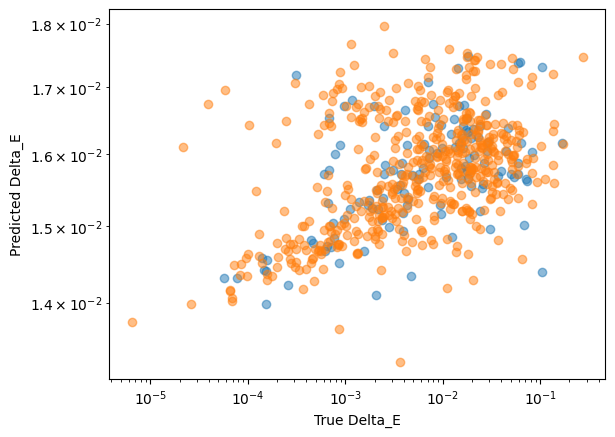

In [ ]:
fig, ax = plt.subplots()
ax.scatter(y_test, test_preds.detach().numpy(), alpha=0.5)
ax.scatter(y_train, train_preds.detach().numpy(), alpha=0.5)
# ax.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
ax.set_xlabel("True Delta_E")
ax.set_ylabel("Predicted Delta_E")
ax.set_xscale('log')
ax.set_yscale('log')